# CSCU9M6 Assignment


In [6]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch_directml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

## Deliverable 1: Data Loading and Preprocessing

In [7]:
ROOT = Path.cwd()
TRAIN_CSV = ROOT / "sign_mnist_train.csv"
TEST_CSV = ROOT /  "sign_mnist_test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"dataset labels: {sorted(train_df['label'].unique())}")

dataset labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


### Fix the labels so that they are 0-23 rather than 0-24 and missing 9

In [8]:
def remap_labels(label):
    if label >= 10:
        return label - 1
    else:
        return label

train_df['label'] = train_df['label'].apply(remap_labels)
test_df['label'] = test_df['label'].apply(remap_labels)

TRAIN_CSV_UPDATED = ROOT / "sign_mnist_train_updated.csv"
TEST_CSV_UPDATED = ROOT /  "sign_mnist_test_updated.csv"

train_df.to_csv(TRAIN_CSV_UPDATED, index=False)
test_df.to_csv(TEST_CSV_UPDATED, index=False)

Create a Pytorch dataset which will use the updated CSV file

In [9]:
class SignLanguageDataset(Dataset):
    def __init__(self, dataframe):
        self.labels = dataframe['label'].astype(int).to_numpy()
        self.pixels = dataframe.drop(columns=['label']).values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.pixels[idx], dtype=torch.float32).view(1, 28, 28)
        x = x / 255.0 # normalize pixels to between 0 and 1
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [10]:
TEST_UPDATED_CSV = ROOT / "sign_mnist_test_updated.csv"
TRAIN_UPDATED_CSV = ROOT /  "sign_mnist_train_updated.csv"

train_df = pd.read_csv(TRAIN_UPDATED_CSV)
test_df = pd.read_csv(TEST_UPDATED_CSV)

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
    )

train_dataset = SignLanguageDataset(train_split_df)
val_dataset = SignLanguageDataset(val_split_df)
test_dataset = SignLanguageDataset(test_df)

print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))
print('Test size:', len(test_dataset))

print(f"dataset labels: {sorted(train_df['label'].unique())}")

Train size: 21964
Val size: 5491
Test size: 7172
dataset labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## Deliverable 2: CNN Architectures
- **Baseline CNN**: Simple CNN using 2 conv layers, 2 pooling layers, and 2 fully connected layers.
- **CNN with Residual Blocks**: Uses skip connections to allow for a deeper network without a vanishing gradient.
- **VGG Style Network**: Uses multiple smaller convolutional layers in place of ones with larger kernals, to learn deeper features with less parameters.

### Model Hyperparameters:

In [28]:
no_of_filters_list = [16,32]
dropouts = [0.3, 0.5]
block_list = [1, 2]

blocks = block_list[0]
dropout = dropouts[0]
no_of_filters = no_of_filters_list[0]

In [12]:
class BaselineCNN(nn.Module):
    """ Basic CNN implementation """
    def __init__(self, num_classes=24):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(1, no_of_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(no_of_filters, no_of_filters * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(no_of_filters * 2 * 7 * 7, 128), # number of filters increased by multiple of 2, max pooling turned the image into 7x7 per filter (28 halved twice)
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.trunk(x)
        x = self.fc_layers(x)
        return x


class ResBlock(nn.Module):
    """ Residual block, uses 2 conv layers with batchnorm and relu, and during the forwarding a skip connection is used """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        res = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + res
        x = self.relu2(x)
        return x


class ResidualCNN(nn.Module):
    """ Deep CNN with residual blocks and increasing channel filters, before using average pooling and a fc layer """
    def __init__(self, num_classes=24, blocks=blocks):
        super().__init__()

        self.conv1 = nn.Conv2d(1, no_of_filters, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(no_of_filters)
        self.relu1 = nn.ReLU()
        self.res_blocks1 = nn.ModuleList([ResBlock(no_of_filters) for _ in range(blocks)])

        self.conv2 = nn.Conv2d(no_of_filters, no_of_filters * 2, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(no_of_filters * 2)
        self.relu2 = nn.ReLU()
        self.res_blocks2 = nn.ModuleList([ResBlock(no_of_filters * 2) for _ in range(blocks)])

        self.conv3 = nn.Conv2d(no_of_filters * 2, no_of_filters * 4, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(no_of_filters * 4)
        self.relu3 = nn.ReLU()
        self.res_blocks3 = nn.ModuleList([ResBlock(no_of_filters * 4) for _ in range(blocks)])

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(no_of_filters * 4, num_classes) # filter count has increased by multiple of 4, average pooling has made the image into a 1x1 single value per filter

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        for block in self.res_blocks1:
            x = block(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        for block in self.res_blocks2:
            x = block(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        for block in self.res_blocks3:
            x = block(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


class VGGNetwork(nn.Module):
    """ VGG style CNN with stages using 2 conv layers with max pooling and dropout before two fc layers """
    def __init__(self, num_classes=24):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Conv2d(1, no_of_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(no_of_filters, no_of_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(no_of_filters, no_of_filters * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(no_of_filters * 2, no_of_filters * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(no_of_filters * 2, no_of_filters * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(no_of_filters * 4, no_of_filters * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(no_of_filters * 4 * 3 * 3, 512), # filter count has increased by multiple of 4, max pooling has made image into 3x3 per filter
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.trunk(x)
        x = self.fc_layers(x)
        return x

## Deliverable 3: Training, Testing, and Evaluation

### Training Hyperparameters

In [13]:
lrs = [0.001,0.005,0.0001]
batch_sizes = [32,64,128]
no_of_epochs = [10,15,20]

lr = lrs[1]
batch_size = batch_sizes[1]
epochs = no_of_epochs[1]
lr_vgg = 0.01

### Training, validation and testing

In [14]:
baseline_model = BaselineCNN()
resnet_model = ResidualCNN()
vgg_model = VGGNetwork()

criterion = nn.CrossEntropyLoss()

if torch_directml.is_available():
    device = torch_directml.device()
else:
    device = torch.device('cpu')

print(device)

baseline_model.to(device)
resnet_model.to(device)
vgg_model.to(device)

baseline_optimizer = optim.SGD(baseline_model.parameters(), lr=lr, momentum=0.9)
resnet_optimizer = optim.SGD(resnet_model.parameters(), lr=lr, momentum=0.9)
vgg_optimizer = optim.SGD(vgg_model.parameters(), lr=lr_vgg, momentum=0.9)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

def validate_model(model, criterion, data_loader):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0) # calculate loss
            running_correct += (preds == labels).sum().item()# accuracy
            total += labels.size(0)# total datapoints seen

    avg_loss = running_loss / total
    accuracy = running_correct / total
    return avg_loss, accuracy

def train_model(model, optimizer, criterion, train_loader, val_loader, epochs):
    start_time = time.time()
    training_metrics = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "training_time": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

        # store metrics in dictionary to be used for evaluation
        train_loss = running_loss / total
        train_acc = running_correct / total
        training_metrics['loss'].append(train_loss)
        training_metrics['accuracy'].append(train_acc)

        val_loss, val_acc = validate_model(model, criterion, val_loader)
        training_metrics['val_loss'].append(val_loss)
        training_metrics['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"train loss: {train_loss:.4f} - train accuracy: {train_acc:.4f} "
            f"val loss: {val_loss:.4f} - val accuracy: {val_acc:.4f}"
        )

    end_time = time.time()
    training_time = end_time - start_time
    training_metrics['training_time'] = training_time
    print(f"Training time: {end_time - start_time:.2f} seconds")
    return training_metrics

print("Baseline CNN: ")
baseline_metrics = train_model(baseline_model, baseline_optimizer, criterion, train_loader, val_loader, epochs)

print("ResNet: ")
resnet_metrics = train_model(resnet_model, resnet_optimizer, criterion, train_loader, val_loader, epochs)

print("VGG: ")
vgg_metrics = train_model(vgg_model, vgg_optimizer, criterion, train_loader, val_loader, epochs)

#torch.save(baseline_model.state_dict(), ROOT / 'baseline_model.pth')
#torch.save(resnet_model.state_dict(), ROOT / 'residual_model.pth')
#torch.save(vgg_model.state_dict(), ROOT / 'vgg_model.pth')

privateuseone:0
Baseline CNN: 
Epoch 1/15 train loss: 3.0959 - train accuracy: 0.0918 val loss: 2.6224 - val accuracy: 0.2626
Epoch 2/15 train loss: 1.6492 - train accuracy: 0.4789 val loss: 0.9762 - val accuracy: 0.6880
Epoch 3/15 train loss: 0.7072 - train accuracy: 0.7689 val loss: 0.4472 - val accuracy: 0.8519
Epoch 4/15 train loss: 0.3089 - train accuracy: 0.9012 val loss: 0.2839 - val accuracy: 0.8920
Epoch 5/15 train loss: 0.1326 - train accuracy: 0.9608 val loss: 0.0760 - val accuracy: 0.9796
Epoch 6/15 train loss: 0.0642 - train accuracy: 0.9845 val loss: 0.0451 - val accuracy: 0.9878
Epoch 7/15 train loss: 0.0281 - train accuracy: 0.9944 val loss: 0.0492 - val accuracy: 0.9867
Epoch 8/15 train loss: 0.0142 - train accuracy: 0.9980 val loss: 0.0071 - val accuracy: 0.9998
Epoch 9/15 train loss: 0.0085 - train accuracy: 0.9991 val loss: 0.0047 - val accuracy: 1.0000
Epoch 10/15 train loss: 0.0034 - train accuracy: 1.0000 val loss: 0.0029 - val accuracy: 1.0000
Epoch 11/15 train 

## Training time for each model:

In [15]:
print(f"Baseline CNN Training Time: {baseline_metrics['training_time']:.2f} seconds")
print(f"ResNet Training Time: {resnet_metrics['training_time']:.2f} seconds")
print(f"VGG Training Time: {vgg_metrics['training_time']:.2f} seconds")

Baseline CNN Training Time: 42.22 seconds
ResNet Training Time: 93.33 seconds
VGG Training Time: 54.56 seconds


## Parameter count for each model:
Reference for finding model's total parameter count in pytorch:

https://saturncloud.io/blog/check-the-total-number-of-parameters-in-a-pytorch-model/#:~:text=To%20check%20the%20number%20of%20parameters%20in%20a%20PyTorch%20model,its%20total%20number%20of%20elements.

In [16]:
total_params_baseline = sum(p.numel() for p in baseline_model.parameters())
print(f"Total Parameters - Baseline CNN: {total_params_baseline}")
total_params_resnet = sum(p.numel() for p in resnet_model.parameters())
print(f"Total Parameters - ResNet: {total_params_resnet}")
total_params_vgg = sum(p.numel() for p in vgg_model.parameters())
print(f"Total Parameters - VGG: {total_params_vgg}")

Total Parameters - Baseline CNN: 208728
Total Parameters - ResNet: 122520
Total Parameters - VGG: 379528


## Training and validation loss over epoch for each model

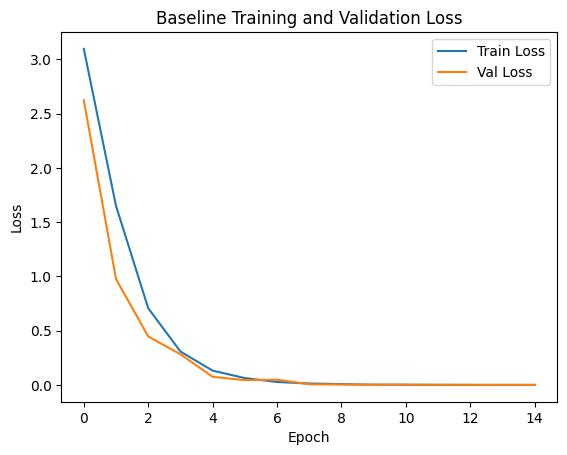

In [17]:
plt.plot(baseline_metrics['loss'], label='Baseline Train Loss')
plt.plot(baseline_metrics['val_loss'], label='Baseline Val Loss')

plt.title('Baseline Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])

plt.show()

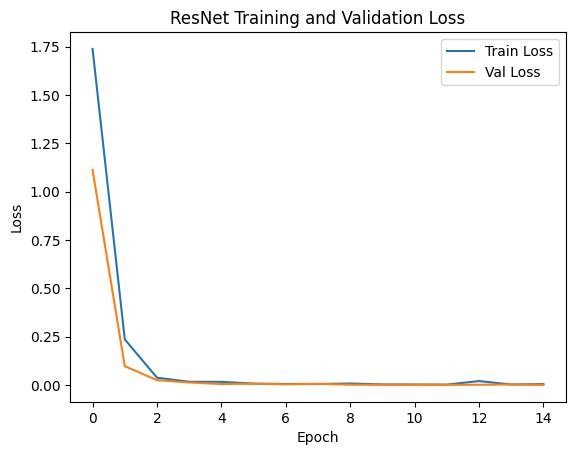

In [18]:
plt.plot(resnet_metrics['loss'], label='ResNet Train Loss')
plt.plot(resnet_metrics['val_loss'], label='ResNet Val Loss')

plt.title('ResNet Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.show()

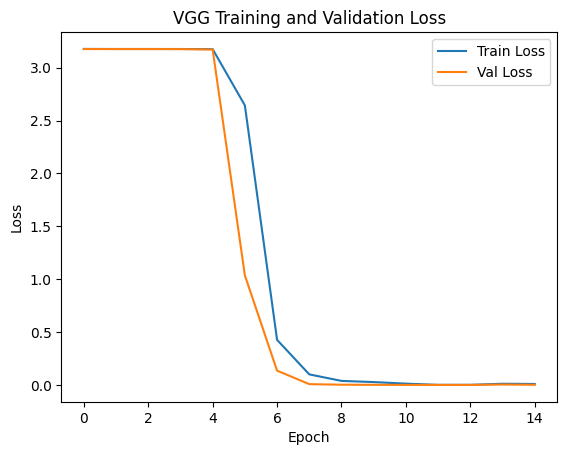

In [19]:
plt.plot(vgg_metrics['loss'], label='VGG Train Loss')
plt.plot(vgg_metrics['val_loss'], label='VGG Val Loss')

plt.title('VGG Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.show()

## Training and Validation Accuracy for each model:

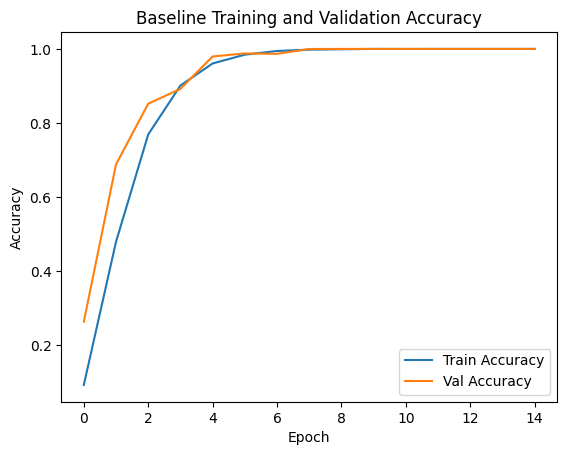

In [20]:
plt.plot(baseline_metrics['accuracy'], label='Baseline Train Accuracy')
plt.plot(baseline_metrics['val_accuracy'], label='Baseline Val Accuracy')

plt.title('Baseline Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Val Accuracy'])

plt.show()

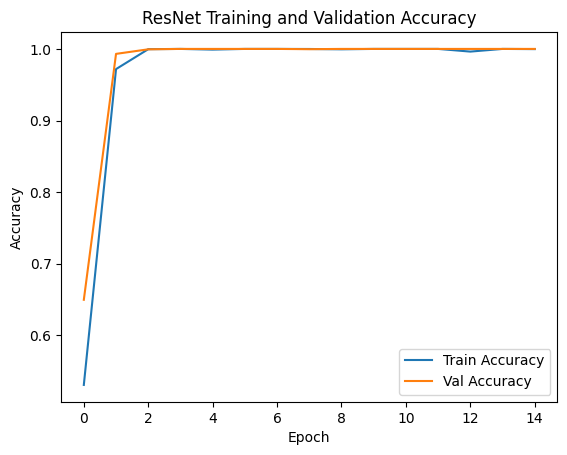

In [21]:
plt.plot(resnet_metrics['accuracy'], label='ResNet Train Accuracy')
plt.plot(resnet_metrics['val_accuracy'], label='ResNet Val Accuracy')

plt.title('ResNet Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Val Accuracy'])

plt.show()

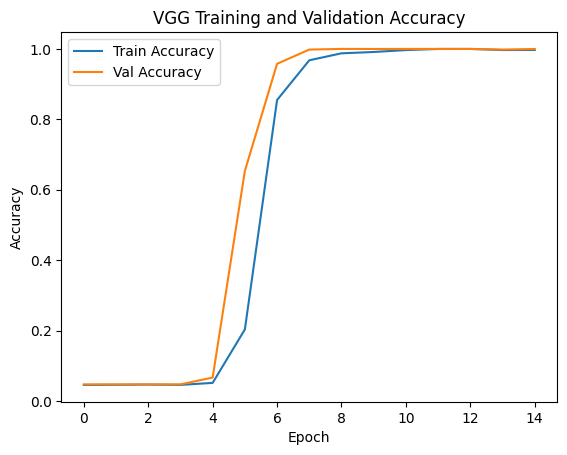

In [22]:
plt.plot(vgg_metrics['accuracy'], label='VGG Train Accuracy')
plt.plot(vgg_metrics['val_accuracy'], label='VGG Val Accuracy')

plt.title('VGG Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Val Accuracy'])

plt.show()

## Testing the final models:

In [23]:
def test_model(model, criterion, data_loader):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0
    all_preds = [] # save predictions and labels for confusion matrix
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = running_loss / total
    accuracy = running_correct / total
    return avg_loss, accuracy, all_labels, all_preds

baseline_test_loss, baseline_test_acc, baseline_labels, baseline_preds = test_model(baseline_model, criterion, test_loader)
resnet_test_loss, resnet_test_acc, resnet_labels, resnet_preds = test_model(resnet_model, criterion, test_loader)
vgg_test_loss, vgg_test_acc, vgg_labels, vgg_preds = test_model(vgg_model, criterion, test_loader)

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(f"ResNet test loss: {resnet_test_loss:.4f}")
print(f"ResNet test accuracy: {resnet_test_acc:.4f}")
print(f"VGG test loss: {vgg_test_loss:.4f}")
print(f"VGG test accuracy: {vgg_test_acc:.4f}")

Baseline test loss: 0.6551
Baseline test accuracy: 0.8766
ResNet test loss: 0.0521
ResNet test accuracy: 0.9888
VGG test loss: 0.2791
VGG test accuracy: 0.9288


## Confusion Matrices for each model

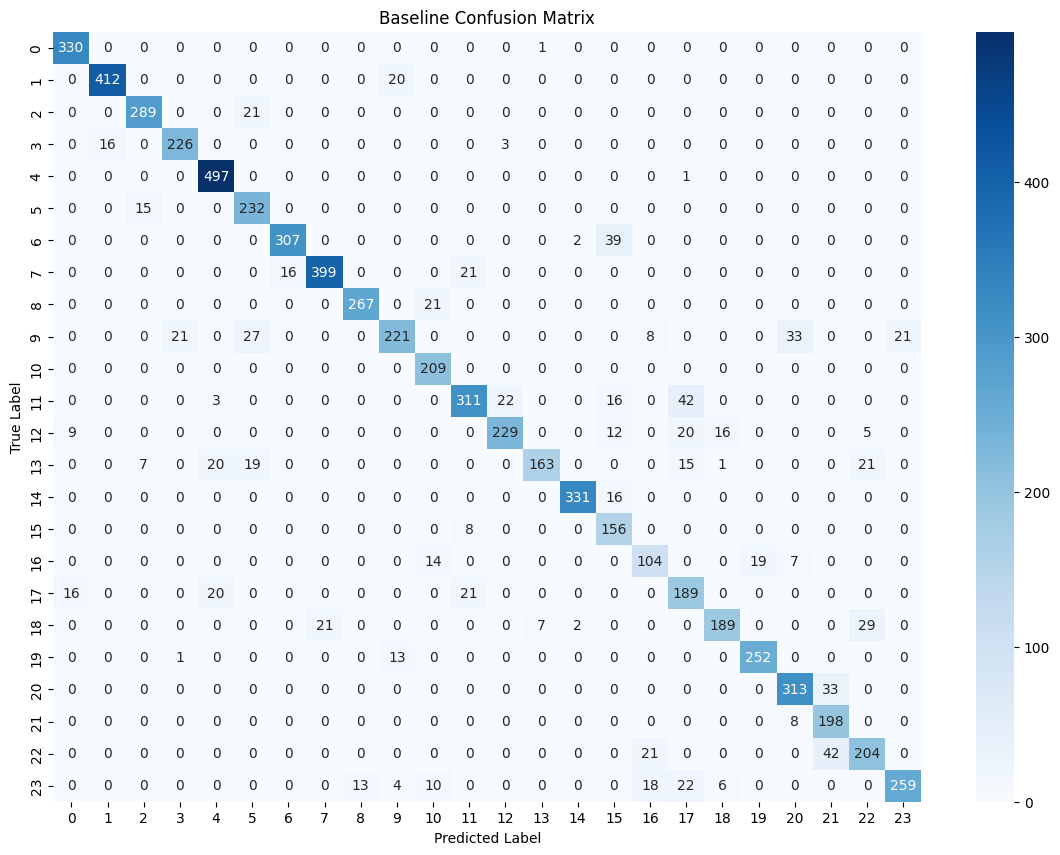

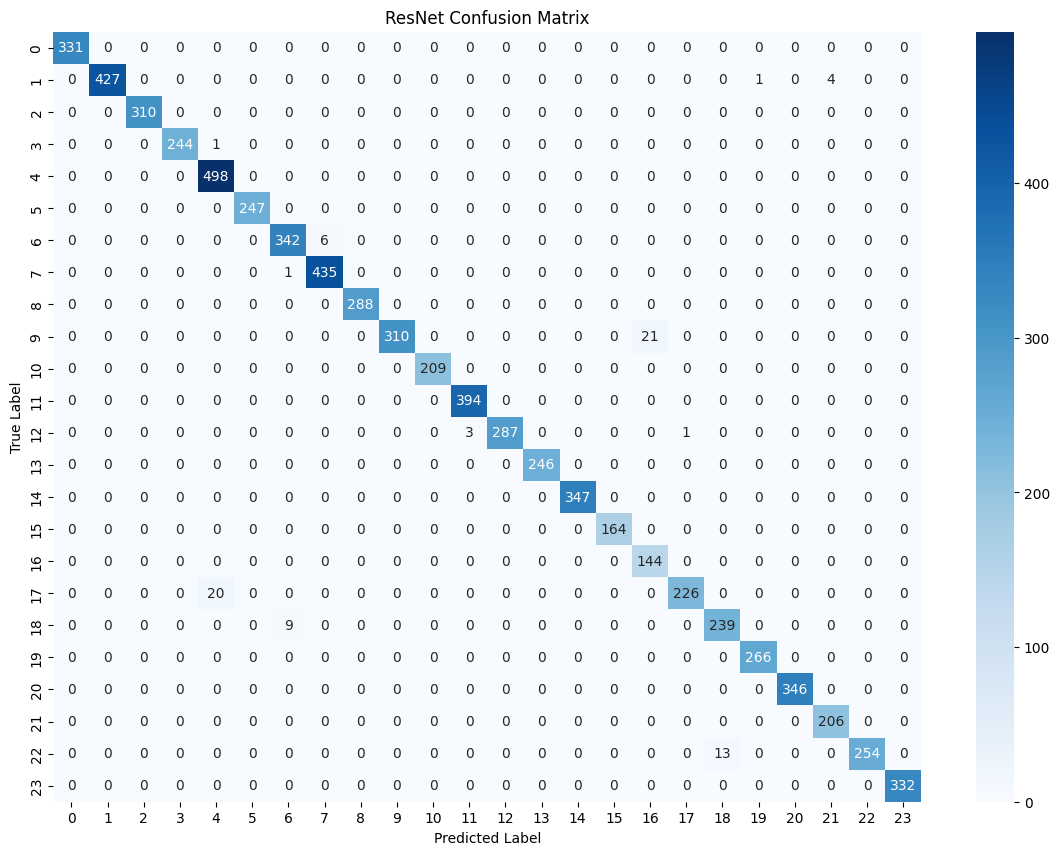

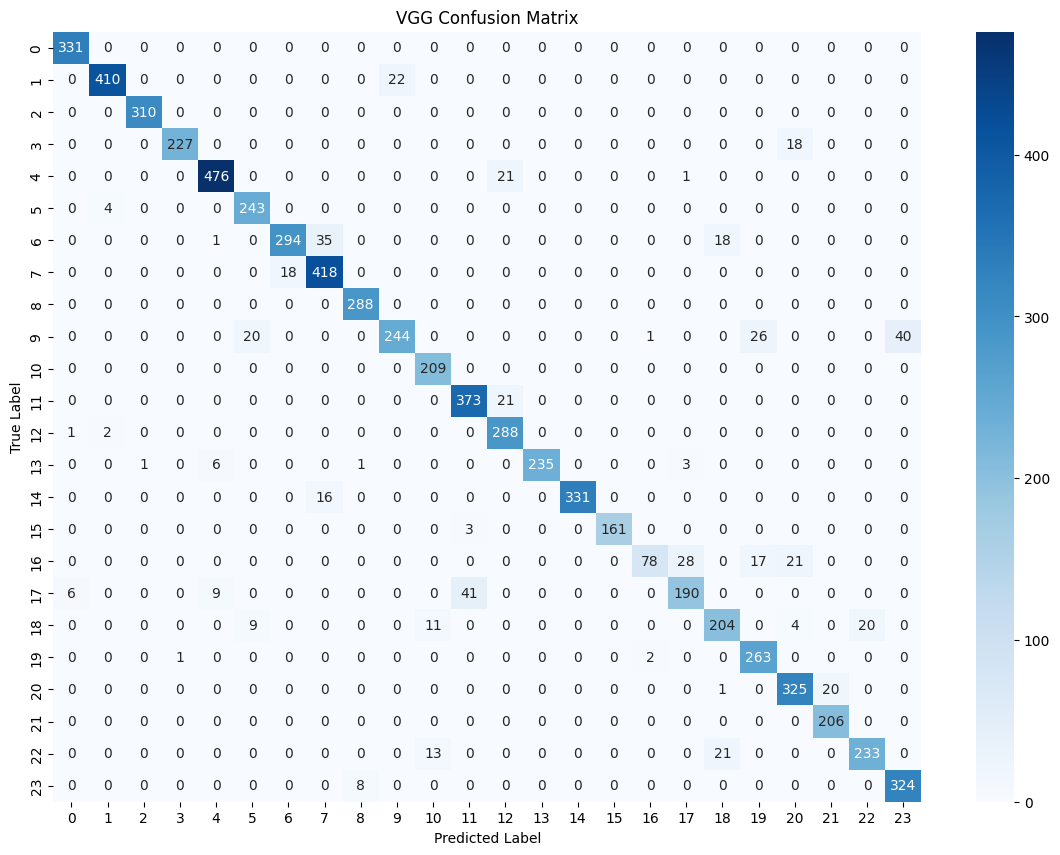

In [27]:
def plot_confusion_matrix_from_labels(y_true, y_pred, class_names, title):
    labels = list(range(len(class_names)))
    plt.figure(figsize=(14, 10))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

class_names = [str(i) for i in range(24)]

plot_confusion_matrix_from_labels(
    baseline_labels, baseline_preds, class_names, "Baseline Confusion Matrix"
)
plot_confusion_matrix_from_labels(
    resnet_labels, resnet_preds, class_names, "ResNet Confusion Matrix"
)
plot_confusion_matrix_from_labels(
    vgg_labels, vgg_preds, class_names, "VGG Confusion Matrix"
)

## Classification Reports for each model

In [25]:
print("Baseline CNN Classification Report:")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))
print("ResNet Classification Report:")
print(classification_report(resnet_labels, resnet_preds, target_names=class_names))
print("VGG Classification Report:")
print(classification_report(vgg_labels, vgg_preds, target_names=class_names))

Baseline CNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       331
           1       0.96      0.95      0.96       432
           2       0.93      0.93      0.93       310
           3       0.91      0.92      0.92       245
           4       0.92      1.00      0.96       498
           5       0.78      0.94      0.85       247
           6       0.95      0.88      0.92       348
           7       0.95      0.92      0.93       436
           8       0.95      0.93      0.94       288
           9       0.86      0.67      0.75       331
          10       0.82      1.00      0.90       209
          11       0.86      0.79      0.82       394
          12       0.90      0.79      0.84       291
          13       0.95      0.66      0.78       246
          14       0.99      0.95      0.97       347
          15       0.65      0.95      0.77       164
          16       0.69      0.72      0.71  

## Random images from the dataset with each model's predicted and true label

Baseline CNN Predictions vs True Labels:


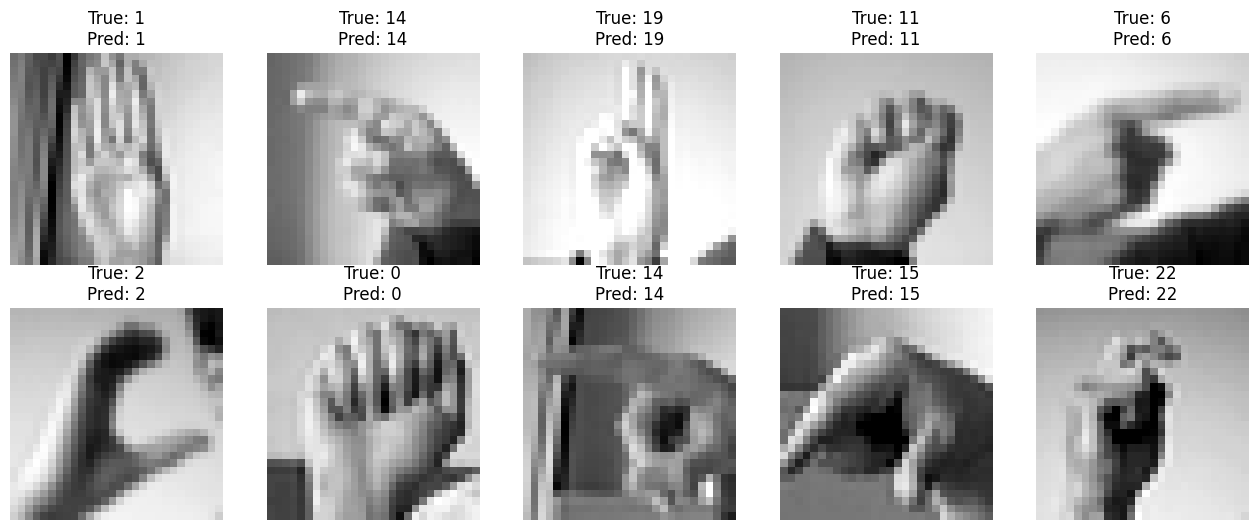

ResNet Predictions vs True Labels:


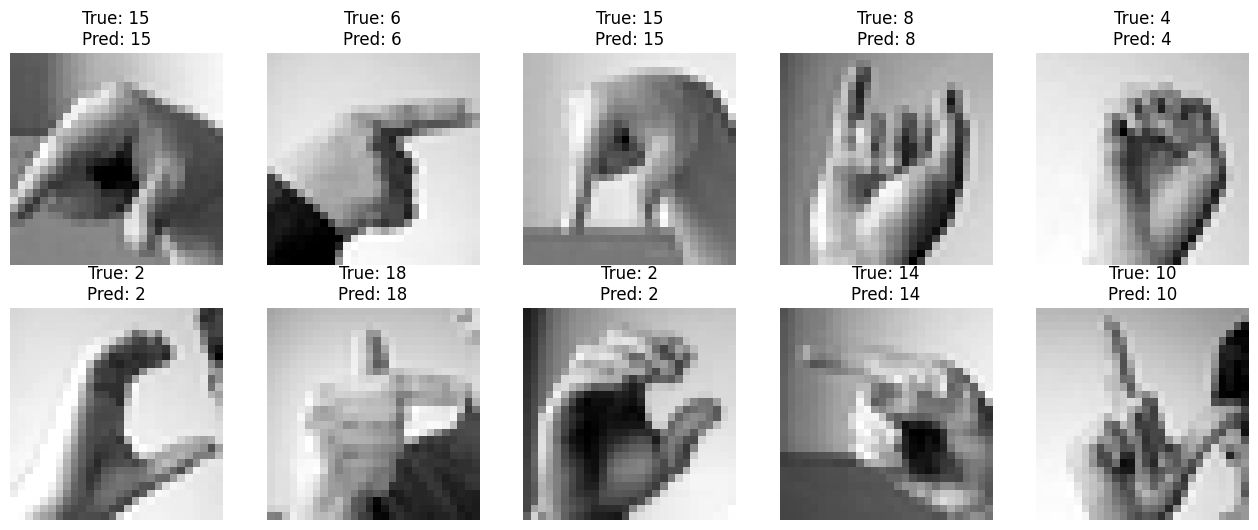

VGG Predictions vs True Labels:


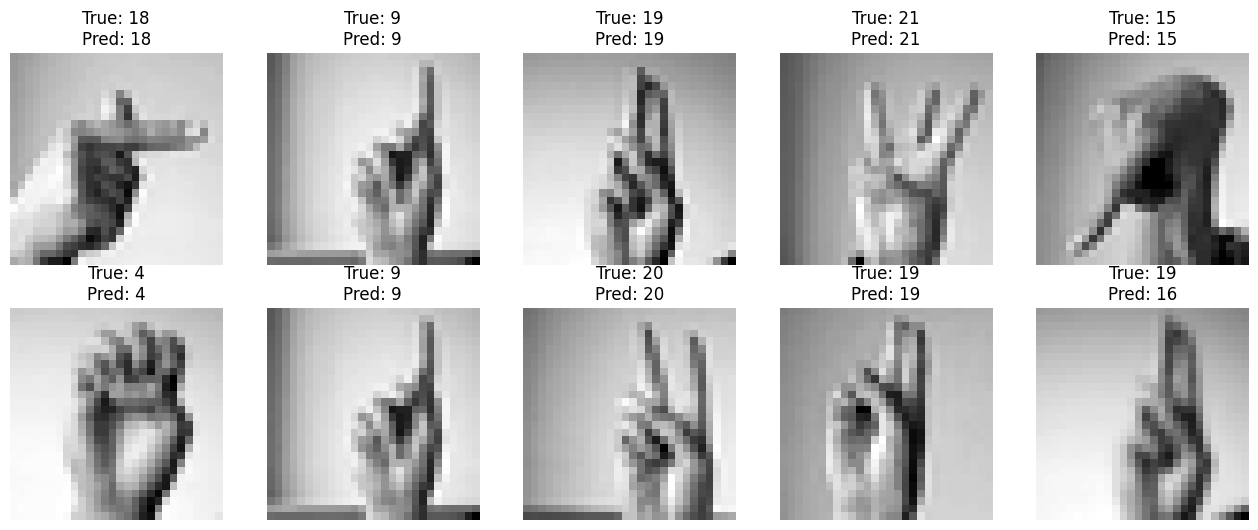

In [26]:
import random

def show_pred_vs_true(dataset, y_true, y_pred, class_names):
    plt.figure(figsize=(16, 16))
    idxs = random.sample(range(len(dataset)), 10)

    for i, idx in enumerate(idxs):
        image, _ = dataset[idx]
        true_label = y_true[idx]
        pred_label = y_pred[idx]

        plt.subplot(5, 5, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis('off')

    plt.show()
print("Baseline CNN Predictions vs True Labels:")
show_pred_vs_true(test_dataset, baseline_labels, baseline_preds, class_names)
print("ResNet Predictions vs True Labels:")
show_pred_vs_true(test_dataset, resnet_labels, resnet_preds, class_names)
print("VGG Predictions vs True Labels:")
show_pred_vs_true(test_dataset, vgg_labels, vgg_preds, class_names)